In [1]:
import pandas as pd

df = pd.read_csv("data1.csv")

In [2]:
print(df.head())

   level_diff  age_diff  freq_match  win_rate_diff  compatible
0           1         1           1           0.13           0
1           1         3           0           0.24           0
2           0         3           1           0.00           1
3           1         5           1           0.16           0
4           0         7           0           0.12           0


In [5]:
from sklearn.preprocessing import PolynomialFeatures
X = df[['level_diff','age_diff','freq_match','win_rate_diff']]
y = df['compatible']

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

feature_names = poly.get_feature_names_out(X.columns)
X_poly_df = pd.DataFrame(X_poly, columns=feature_names)
print(X_poly_df.head())

   level_diff  age_diff  freq_match  win_rate_diff  level_diff^2  \
0         1.0       1.0         1.0           0.13           1.0   
1         1.0       3.0         0.0           0.24           1.0   
2         0.0       3.0         1.0           0.00           0.0   
3         1.0       5.0         1.0           0.16           1.0   
4         0.0       7.0         0.0           0.12           0.0   

   level_diff age_diff  level_diff freq_match  level_diff win_rate_diff  \
0                  1.0                    1.0                      0.13   
1                  3.0                    0.0                      0.24   
2                  0.0                    0.0                      0.00   
3                  5.0                    1.0                      0.16   
4                  0.0                    0.0                      0.00   

   age_diff^2  age_diff freq_match  age_diff win_rate_diff  freq_match^2  \
0         1.0                  1.0                    0.13      

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_poly_df, y, test_size = 0.2, random_state=42)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

Accuracy: 0.8888888888888888


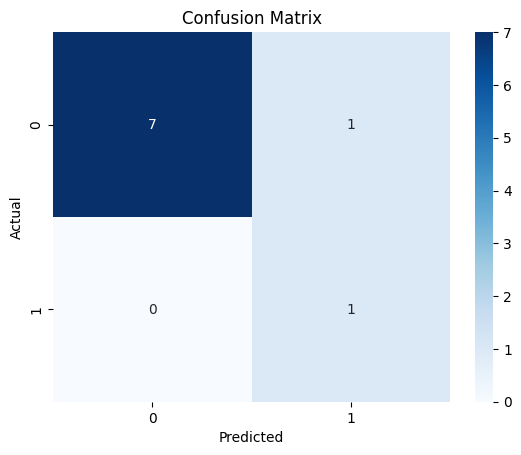

In [15]:
from sklearn.metrics import confusion_matrix, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

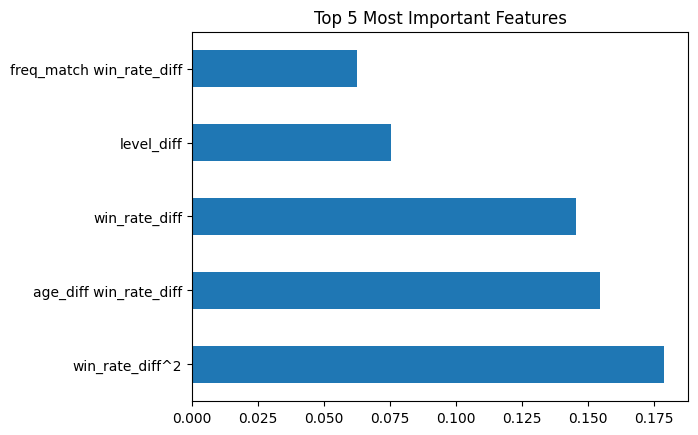

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

importances = model.feature_importances_
feature_names = X_poly_df.columns
feat_importances = pd.Series(importances, index=feature_names) 
feat_importances.nlargest(5).plot(kind='barh') 
plt.title("Top 5 Most Important Features") 
plt.show()